In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Evolution of NFL Offenses (2003-2023)

## Section 1: Evaluating and Cleaning the Data

First, we need to import our data set and evaluate essential quantities and faithfulness of the data. The data set we'll be utilizing for this project features extensive regular season statistics for NFL teams spanning 21 years, from 2003-2023.

In [4]:
nfl_data = pd.read_csv('team_stats_2003_2023.csv')
nfl_data.head()

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,...,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,2003,New England Patriots,14,2,0.875,348,238,110,6.9,16,...,9,3.4,91,111,998,26,27.9,11.3,-136.51,NaN
1,2003,Miami Dolphins,10,6,0.625,311,261,50,3.1,16,...,14,3.7,99,103,913,22,28.1,17.2,-177.92,NaN
2,2003,Buffalo Bills,6,10,0.375,243,279,-36,-2.3,16,...,13,3.9,96,106,891,22,21.9,17.6,-230.07,NaN
3,2003,New York Jets,6,10,0.375,283,299,-16,-1.0,16,...,8,4.0,78,69,550,15,32.4,11.8,-107.89,NaN
4,2003,Baltimore Ravens,10,6,0.625,391,281,110,6.9,16,...,18,4.8,115,126,970,23,31.8,16.6,-220.50,NaN


In [5]:
# Evaluating dimensionality of our data
nfl_data.shape

(672, 35)

Our source for this data set (https://www.kaggle.com/datasets/nickcantalupa/nfl-team-data-2003-2023) claims that we have data for 672 teams measured with 35 variables, so our dimensionality looks good here.

In [7]:
# Check for duplicate rows
dup = nfl_data.duplicated().sum()
dup

0

No duplicate records in our data.

In [9]:
# Look for NAs
np.sum(nfl_data.isna())

C:\Users\maxim\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


year                      0
team                      0
wins                      0
losses                    0
win_loss_perc             0
points                    0
points_opp                0
points_diff               0
mov                     320
g                         0
total_yards               0
plays_offense             0
yds_per_play_offense      0
turnovers                 0
fumbles_lost              0
first_down                0
pass_cmp                  0
pass_att                  0
pass_yds                  0
pass_td                   0
pass_int                  0
pass_net_yds_per_att      0
pass_fd                   0
rush_att                  0
rush_yds                  0
rush_td                   0
rush_yds_per_att          0
rush_fd                   0
penalties                 0
penalties_yds             0
pen_fd                    0
score_pct                 0
turnover_pct              0
exp_pts_tot               0
ties                    352
dtype: int64

We have 352 NA values for ties, which is to be expected considering ties are typically rare occurrences, but we also have 320 NA values in mov (margin of victory), which should not be the case. We can fix this column manually with a computation if we know the formula for average mov:

In [11]:
nfl_data["mov"] = nfl_data["points_diff"] / nfl_data["g"] # Dividing total point differential by games played will give us average mov

For aesthetic purposes, we'll also change our ties column such that NA values are just replaced with zero.

In [13]:
nfl_data["ties"] = nfl_data["ties"].fillna(0) # Replace all NA values in the ties column with zero

In [14]:
# Count number of non-missing values
nfl_data.count()

year                    672
team                    672
wins                    672
losses                  672
win_loss_perc           672
points                  672
points_opp              672
points_diff             672
mov                     672
g                       672
total_yards             672
plays_offense           672
yds_per_play_offense    672
turnovers               672
fumbles_lost            672
first_down              672
pass_cmp                672
pass_att                672
pass_yds                672
pass_td                 672
pass_int                672
pass_net_yds_per_att    672
pass_fd                 672
rush_att                672
rush_yds                672
rush_td                 672
rush_yds_per_att        672
rush_fd                 672
penalties               672
penalties_yds           672
pen_fd                  672
score_pct               672
turnover_pct            672
exp_pts_tot             672
ties                    672
dtype: int64

No more missing values!

Crucially, we need to ensure that we have a count of 21 records for each team since there have been no additional franchise expansions across the NFL since 2002. However, several teams have rebranded in recent years which may or may not have been accounted for. Let's see if this is reflected in our data:

In [17]:
nfl_data['team'].value_counts()

team
New England Patriots        21
Seattle Seahawks            21
Tampa Bay Buccaneers        21
New Orleans Saints          21
Carolina Panthers           21
Detroit Lions               21
Chicago Bears               21
Minnesota Vikings           21
Green Bay Packers           21
New York Giants             21
Miami Dolphins              21
Dallas Cowboys              21
Philadelphia Eagles         21
San Francisco 49ers         21
Arizona Cardinals           21
Denver Broncos              21
Kansas City Chiefs          21
Houston Texans              21
Jacksonville Jaguars        21
Tennessee Titans            21
Indianapolis Colts          21
Cleveland Browns            21
Pittsburgh Steelers         21
Cincinnati Bengals          21
Baltimore Ravens            21
New York Jets               21
Buffalo Bills               21
Atlanta Falcons             21
Washington Redskins         17
Oakland Raiders             17
San Diego Chargers          14
St. Louis Rams              13
Los

Sure enough, we have several franchises with disjointed records in our data as a result of relocation/rebranding. We need to merge our rebranded franchise records with their older franchise records so we have an accurate and complete history of each franchise over these 21 seasons.

In [19]:
# We can efficiently accomplish this by creating a dictionary and using the replace method (https://pandas.pydata.org/docs/reference/api/pandas.Series.replace.html)
franchise_merge = {'Washington Redskins': 'Washington Commanders', 'Washington Football Team': 'Washington Commanders', 'Oakland Raiders': 'Las Vegas Raiders', 'San Diego Chargers': 'Los Angeles Chargers', 'St. Louis Rams': 'Los Angeles Rams'}
nfl_data['team'] = nfl_data['team'].replace(franchise_merge)

Now we'll take the value counts once again, where we should have 21 records for each franchise.

In [21]:
nfl_data['team'].value_counts()

team
New England Patriots     21
Miami Dolphins           21
San Francisco 49ers      21
Seattle Seahawks         21
Los Angeles Rams         21
Atlanta Falcons          21
Tampa Bay Buccaneers     21
New Orleans Saints       21
Carolina Panthers        21
Detroit Lions            21
Chicago Bears            21
Minnesota Vikings        21
Green Bay Packers        21
New York Giants          21
Washington Commanders    21
Dallas Cowboys           21
Philadelphia Eagles      21
Los Angeles Chargers     21
Las Vegas Raiders        21
Denver Broncos           21
Kansas City Chiefs       21
Houston Texans           21
Jacksonville Jaguars     21
Tennessee Titans         21
Indianapolis Colts       21
Cleveland Browns         21
Pittsburgh Steelers      21
Cincinnati Bengals       21
Baltimore Ravens         21
New York Jets            21
Buffalo Bills            21
Arizona Cardinals        21
Name: count, dtype: int64

## Section 2: Exploration

Now that we've evaluated and cleaned components of our data such as dimensionality, missing values, or other somewhat apparent issues, we can now begin to identify important features of the data, such as summary statistics for key variables and identifying outliers while we explore the data set and test some hypotheses.

In [24]:
# Examining the data types of our columns
nfl_data.dtypes

year                      int64
team                     object
wins                      int64
losses                    int64
win_loss_perc           float64
points                    int64
points_opp                int64
points_diff               int64
mov                     float64
g                         int64
total_yards               int64
plays_offense             int64
yds_per_play_offense    float64
turnovers                 int64
fumbles_lost              int64
first_down                int64
pass_cmp                  int64
pass_att                  int64
pass_yds                  int64
pass_td                   int64
pass_int                  int64
pass_net_yds_per_att    float64
pass_fd                   int64
rush_att                  int64
rush_yds                  int64
rush_td                   int64
rush_yds_per_att        float64
rush_fd                   int64
penalties                 int64
penalties_yds             int64
pen_fd                    int64
score_pc

While we only have one true categorical variable in our data set, we can still perform cross-tabulation by assigning numerical variables into bins, which we'll do later.

In [26]:
# Examining some basic statistics for each column of our data
nfl_data.describe()

,year,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,...,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
count,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,...,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.00000
mean,2013.000000,8.050595,8.050595,0.500246,358.633929,358.633929,0.000000,0.001450,16.139881,5463.895833,...,13.462798,4.199554,99.775298,101.494048,849.501488,27.889881,34.093304,12.561756,-35.937113,0.03869
std,6.059811,3.093255,3.086020,0.191452,72.092050,57.889328,100.684601,6.246326,0.347122,628.209466,...,5.170285,0.440718,20.837354,16.145851,146.167034,7.251892,6.730800,3.206515,120.556255,0.19300
min,2003.000000,0.000000,0.000000,0.000000,168.000000,201.000000,-261.000000,-16.312500,16.000000,3587.000000,...,2.000000,3.100000,53.000000,55.000000,415.000000,9.000000,16.400000,4.000000,-358.270000,0.00000
25%,2008.000000,6.000000,6.000000,0.375000,305.000000,316.750000,-75.000000,-4.640625,16.000000,5030.250000,...,10.000000,3.900000,84.000000,91.000000,751.750000,23.000000,29.200000,10.200000,-124.015000,0.00000
50%,2013.000000,8.000000,8.000000,0.500000,359.000000,356.500000,-1.000000,-0.058824,16.000000,5467.500000,...,13.000000,4.200000,98.000000,102.000000,852.500000,27.000000,33.900000,12.400000,-40.970000,0.00000
75%,2018.000000,10.000000,10.000000,0.625000,406.000000,398.000000,75.250000,4.630515,16.000000,5900.250000,...,17.000000,4.500000,112.250000,112.000000,941.250000,33.000000,38.800000,14.800000,49.795000,0.00000
max,2023.000000,16.000000,16.000000,1.000000,606.000000,519.000000,315.000000,19.687500,17.000000,7474.000000,...,32.000000,5.500000,188.000000,163.000000,1358.000000,50.000000,52.700000,25.000000,298.140000,1.00000


To get started with our visualizations, let's examine the mean points scored per year by first creating a table.

In [28]:
mean_pts_yr = nfl_data.groupby('year')[['points']].mean()
mean_pts_yr

,points
year,
2003,333.31250
2004,343.75000
2005,329.87500
2006,330.53125
2007,347.00000
2008,352.46875
2009,343.46875
2010,352.59375
2011,354.87500


As a visualization:

<Axes: xlabel='year', ylabel='points'>

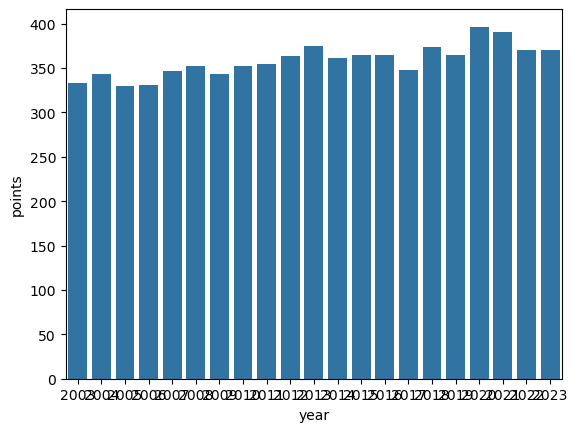

In [30]:
sns.barplot(data=mean_pts_yr, x='year', y='points')

Unsurprisingly, both our table and our plot reveal that mean points scored have steadily been increasing year by year for the past 21 seasons, which supports the common talking point that NFL offenses have improved in the modern era. 

#### Deeper Dive

Our extensive data set also provides us with plenty of other data that may help explain how NFL offenses have evolved. As one example, it might be interesting to analyze some more rushing and passing statistics from our most and least recent years and see what our results may tell us.

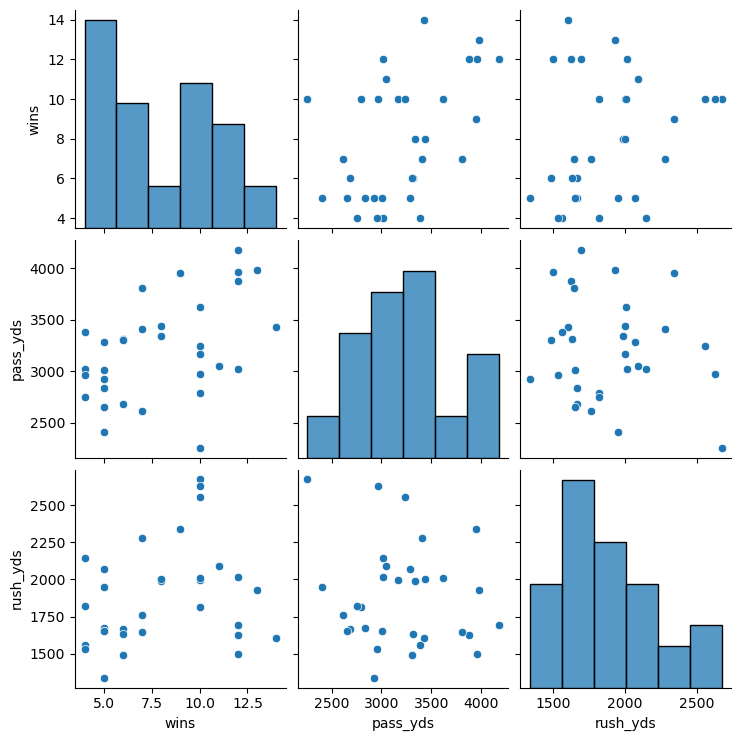

In [33]:
# See if there is a strong relationship between rush yards, pass yards, and wins in 2003
sns.pairplot(nfl_data[nfl_data['year'] == 2003][['wins', 'pass_yds', 'rush_yds']])
plt.show()
plt.close()

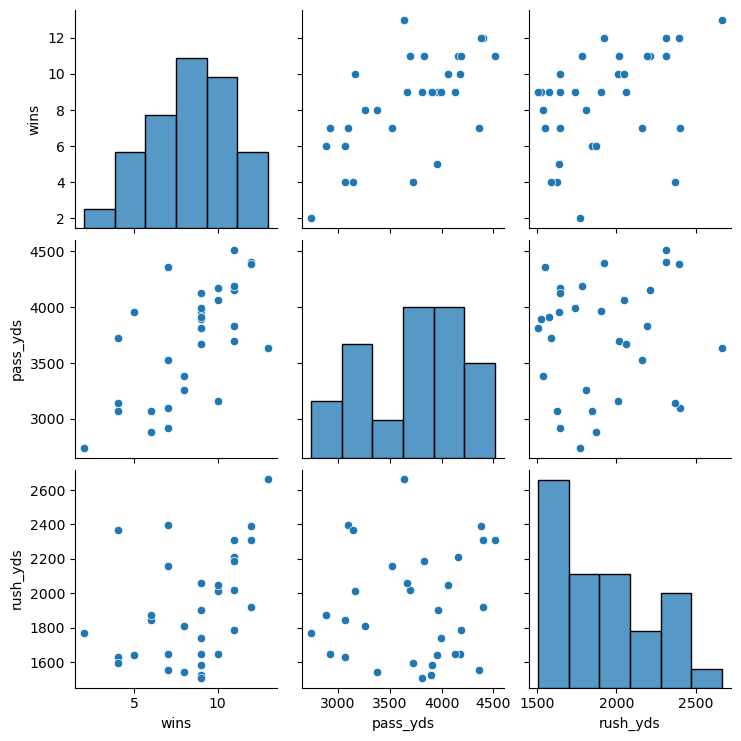

In [34]:
# See if there is a strong relationship between rush yards, pass yards, and wins in 2023
sns.pairplot(nfl_data[nfl_data['year'] == 2023][['wins', 'pass_yds', 'rush_yds']])
plt.show()
plt.close()

##### Interpretation

While these plots may appear a bit overwhelming, we only really need to compare a few things to extrapolate some important information. Firstly, we can see from the pass yards histogram (middle plot) that teams are throwing the football significantly more, as our 2023 histogram is left-skewed with a higher starting point on the x-axis while our 2003 histogram is slightly right-skewed. We also see the rushing numbers have trended down overall in 2023 while our wins are more normally distributed. To summarize, this indicates that more teams are winning more games, passing the ball more, and rushing the ball less in 2023 compared to 2003, which is also reflected in our scatterplots demonstrating some correlation (albeit not too strong) between yards and wins.

#### Talent vs Schematics

While we certainly would expect play attempts to strongly correlate with total yardage volumes, we do also have data on yards-per-play by team. At the end of the day, more talented rosters often win more games, regardless of playcalling tendencies, which may help explain some potential outliers we've observed (especially related to rushing). That being said, let's dive deeper into our yards-per-play variable, where we can use cross-tabulation after we convert our two variables into categorical data.

In [37]:
# We first need to learn about our columns so we can identify our bin cutoffs
nfl_data['yds_per_play_offense'].describe()

count    672.000000
mean       5.340476
std        0.507939
min        3.900000
25%        5.000000
50%        5.300000
75%        5.700000
max        6.800000
Name: yds_per_play_offense, dtype: float64

In [38]:
nfl_data['wins'].describe()

count    672.000000
mean       8.050595
std        3.093255
min        0.000000
25%        6.000000
50%        8.000000
75%       10.000000
max       16.000000
Name: wins, dtype: float64

Everything looks good with our column data.

In [40]:
# We can make four bins for each column and know our bin cutoffs since we can see our data quartiles above

nfl_data['yds_per_bin'] = pd.qcut(nfl_data['yds_per_play_offense'], 4, labels=['Poor', 'Fair', 'Good', 'Elite']) # https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
nfl_data['wins_bin'] = pd.qcut(nfl_data['wins'], 4, labels=['Poor', 'Fair', 'Good', 'Elite'])
cross_tab = pd.crosstab(nfl_data['yds_per_bin'], nfl_data['wins_bin']) # https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html
cross_tab

wins_bin,Poor,Fair,Good,Elite
yds_per_bin,,,,
Poor,116,41,25,13
Fair,49,46,37,24
Good,36,38,49,47
Elite,11,30,35,75


Unsurprisingly, teams with 'poor' yards-per-play overwhelmingly find themselves within the 'poor' category for wins, while elite teams typically fall within the elite category for yards-per-play. Interestingly though, there isn't as strong of an association between fair/good yards-per-play and fair/good win categorization. This may suggest that most teams fall into these categories, while poor/elite teams are overwhelmingly likely to fall within the poor/elite yards-per-play categories, respectively.

#### Rule Changes

Of course, the NFL has changed many rules over the years in the name of "player safety," so it might be interesting, since we have the data, to examine penalties and see if those numbers have increased over the years and how they might relate to other interesting variables.

In [43]:
# We can use the groupby method just like earlier
nfl_data.groupby('year')[['penalties']].mean()

,penalties
year,
2003,105.56250
2004,111.56250
2005,116.25000
2006,95.15625
2007,91.62500
2008,89.62500
2009,94.68750
2010,96.87500
2011,102.75000


In [44]:
# Compute correlation for easy comprehension
nfl_data[['penalties', 'year']].corr()

,penalties,year
penalties,1.000000,-0.052886
year,-0.052886,1.000000


##### Interpretation

Our correlation matrix gives us a very small negative value for the correlation between penalties and years. Meaning, there exists almost zero correlation between penalties and years, which may come as a surprise to many. A popular opinion among NFL fans and TV personalities seems to be that modern offenses are more prolific, at least in part, due to an increase in rule changes that harshly penalize defensive players that engage in certain kinds of physical contact. However, there exists a slightly negative correlation here, which may help discredit that narrative.

#### Do Penalties Create Unfair Outcomes?

To explore further, another analysis we could perform would be to examine the relationship between penalties and wins. A typical sports fan might blame referees for their favorite team's loss, but does there exist any evidence to support this claim?

In [47]:
# Computing the mean correlation between penalties and wins in our data
penalties = nfl_data['penalties'].corr(nfl_data['wins'])
penalties

-0.11604225995335506

No, it wouldn't appear so.

## Section 3: Inference

After thoroughly cleaning and exploring our data, we now need to formulate relevant hypotheses about our data as a method of supporting or countering a narrative. While we thoroughly explored our data in the previous section, we will narrow down our focus in part 3 to answer what we would really like to know.

#### Pass and Rush Yards vs Points

A common narrative regarding the evolution of NFL offenses seems to be that teams are higher scoring in the present day largely in part due to more pass-friendly offensive schemes, so it might be interesting to take a broad look at our data over these 21 seasons and examine the relationship between points and pass/rush yards. This will be the focal point of the analysis regarding hypothesis testing, so let's begin with a question:

**In terms of overall volume statistics, do passing yards impact scoring more than rushing yards?**

***Null Hypothesis***: Passing yards do not impact scoring more than rushing yards.

***Alternative Hypothesis***: Passing yards impact scoring more than rushing yards.

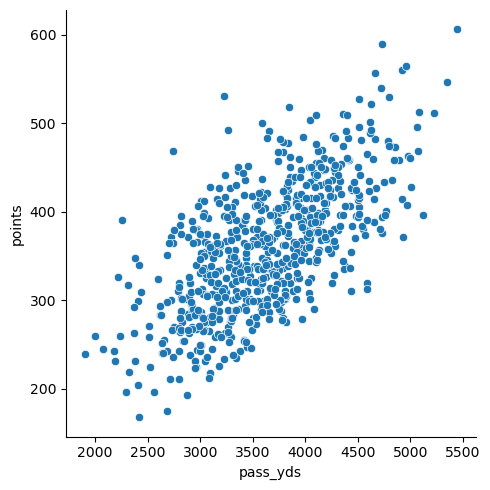

In [54]:
# Let's examine a scatterplot between passing yards and points as our variables
sns.relplot(data=nfl_data, x="pass_yds", y="points");

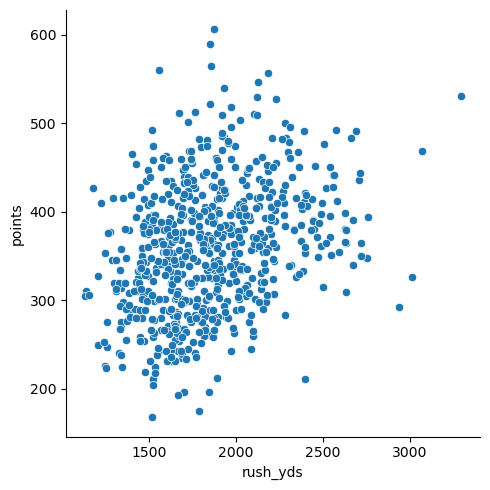

In [55]:
# Now for rushing yards
sns.relplot(data=nfl_data, x='rush_yds', y='points');

Interestingly, we observe an overall strong, positive relationship between both passing yards and points and rushing yards and points. While we can readily identify more outliers in the rush yards vs points figure, the trend is overall still positive. However, we can use linear regression to learn more:

In [57]:
from sklearn.linear_model import LinearRegression

# We need to define models for both of our regressions
pass_model = LinearRegression()
pass_reg = pass_model.fit(nfl_data[['pass_yds']], nfl_data['points'])

rush_model = LinearRegression()
rush_reg = rush_model.fit(nfl_data[['rush_yds']], nfl_data['points'])

In [58]:
pass_reg.coef_

array([0.07768792])

In [59]:
rush_reg.coef_

array([0.070005])

These computations reflect our slopes for each model. If everything goes correct, we should see somewhat of a visual difference between the regression lines in our two plots we're about to create.

In [61]:
# Creating predictors for both regression models
xs = np.linspace(np.min(nfl_data['pass_yds']), np.max(nfl_data['pass_yds']), 100)

b1 = pass_reg.coef_
b0 = pass_reg.intercept_
preds = b1 * xs + b0

xs_2 = np.linspace(np.min(nfl_data['rush_yds']), np.max(nfl_data['rush_yds']), 100)

b1_2 = rush_reg.coef_
b0_2 = rush_reg.intercept_
preds_2 = b1_2 * xs_2 + b0_2

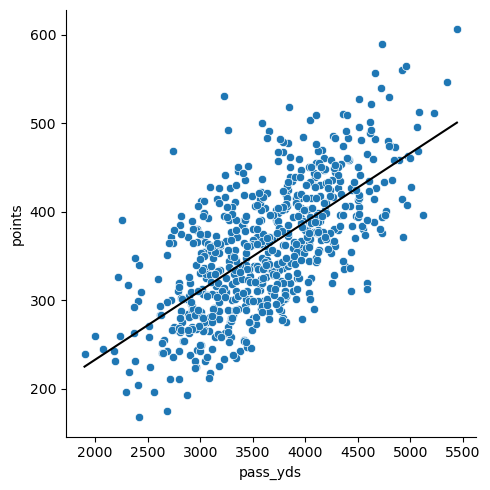

In [62]:
sns.relplot(data = nfl_data, x = "pass_yds", y = "points")
sns.lineplot(x = xs, y =  preds, c = "black");

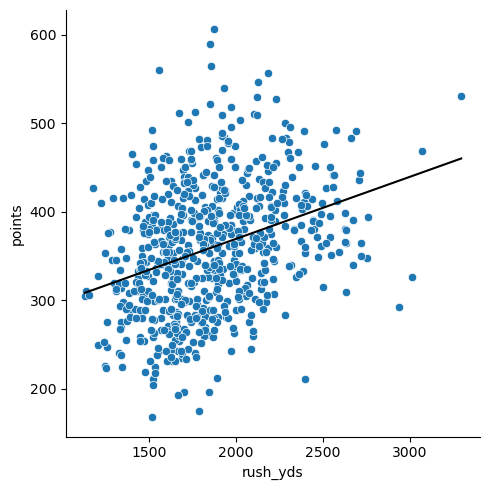

In [63]:
sns.relplot(data = nfl_data, x = "rush_yds", y = "points")
sns.lineplot(x = xs_2, y =  preds_2, c = "black");

As demonstrated with our regression lines, we can observe a stronger positive correlation between passing yards and points than rushing yards and points. Regardless, we will conduct deeper analysis utilizing ordinary least squares (OLS) and observe our outputs.

In [65]:
import statsmodels.api as sm

# Using Ordinary Least Squares (OLS) https://www.statsmodels.org/stable/api.html
X_both = sm.add_constant(nfl_data[['pass_yds', 'rush_yds']])
combined_model = sm.OLS(nfl_data['points'], X_both).fit()
print(combined_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 points   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     813.0
Date:                Sun, 03 May 2026   Prob (F-statistic):          8.45e-180
Time:                        15:42:12   Log-Likelihood:                -3413.6
No. Observations:                 672   AIC:                             6833.
Df Residuals:                     669   BIC:                             6847.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -183.9972     13.873    -13.263      0.0

In [66]:
x_pass = sm.add_constant(nfl_data['pass_yds'])
pass_sum = sm.OLS(nfl_data['points'], x_pass).fit()

In [67]:
pass_sum.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 points   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     534.4
Date:                Sun, 03 May 2026   Prob (F-statistic):           2.20e-87
Time:                        15:42:12   Log-Likelihood:                -3630.8
No. Observations:                 672   AIC:                             7266.
Df Residuals:                     670   BIC:                             7275.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         77.6387     12.331      6.296      0.000      53.426     101.851
pass_yds       0.0777      0.003     23.117      0.000       0.071       0.084
==============================================================================
Omnibus:                       13.598   Durbin-Watson:                   2.116
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.169
Skew:                           0.351   Prob(JB):                     0.000838
Kurtosis:                       2.886   Cond. No.                     2.18e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.18e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [68]:
x_rush = sm.add_constant(nfl_data['rush_yds'])
rush_sum = sm.OLS(nfl_data['points'], x_rush).fit()

In [69]:
rush_sum.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 points   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     83.72
Date:                Sun, 03 May 2026   Prob (F-statistic):           6.76e-19
Time:                        15:42:13   Log-Likelihood:                -3788.2
No. Observations:                 672   AIC:                             7580.
Df Residuals:                     670   BIC:                             7590.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        229.3402     14.372     15.957      0.000     201.121     257.560
rush_yds       0.0700      0.008      9.150      0.000       0.055       0.085
==============================================================================
Omnibus:                       10.924   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.037
Skew:                           0.311   Prob(JB):                      0.00401
Kurtosis:                       3.086   Cond. No.                     1.03e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.03e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Does the observed effect make sense?** Yes. We can determine from our very small p-values (which show up as 0.000 since they are so small) that both passing and rushing yards are significant components of scoring points. 

**Does the effect matter?**

From our coefficients, we see that our pass_yds coefficient is 0.0777 and our rush_yds coefficient is 0.0700. Meaning, for every additional yard of each type, a team would be expected to score 0.0777 or 0.0700 more points.

**So what is our conclusion from this analysis?**
We can conclude that passing yards carry more of a positive impact on scoring than rushing yards, albeit, not by a large margin. A caveat with this data is that we don't account for game scripts or defense/special teams performance. Our analysis is a bit limited since our variables are isolated, but we can ultimately conclude that passing yards carry more impact on scoring, which makes sense that the modern NFL features more pass-friendly offenses since we observed scoring increasing consistently over the past 21 seasons.

## Section 4: Prediction

Finally, we will model the data to predict unobserved values utilizing multiple linear regression, as this will provide us a more comprehensive understand of how each yardage type impacts scoring while controlling for the other. We will compare total points scored in a season to pass and rush yards and calculate error across each of our necessary sets. 

In [75]:
from sklearn.model_selection import train_test_split

np.random.seed(45)

X = nfl_data[['pass_yds', 'rush_yds']]
Y = nfl_data['points']

X_train, X_Holdout, Y_train, Y_holdout = train_test_split(X, Y, test_size = 0.1) # Split 10% of data for test set

X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.1) # Creating validation set using another 10%

linear_model = LinearRegression()
linear_model.fit(X_train, Y_train) # We use training data to fit the model

LinearRegression()

In [76]:
# Creating predictions for each set
y_train_pred = linear_model.predict(X_train)
y_val_pred = linear_model.predict(X_valid)
y_test_pred = linear_model.predict(X_Holdout)

In [77]:
def rmse(actual_y, predicted_y):
    return np.sqrt(np.mean((actual_y - predicted_y)**2)) 

In [78]:
train_error = rmse(Y_train, y_train_pred)
valid_error = rmse(Y_valid, y_val_pred)
holdout_error = rmse(Y_holdout, y_test_pred)

print("Training RMSE:", train_error)
print("Validation RMSE:", valid_error)
print("Holdout RMSE:", holdout_error)

Training RMSE: 38.856592120660544
Validation RMSE: 38.93578303423031
Holdout RMSE: 39.32953986891187


#### Conclusion:
It appears that our model appropriately and consistently fits our error across all three sets. While ~39 points is a notable error, we must remember that this model uses total points scored in a season, not points per individual game. This lack of difference between sets serves as an indication that our model is not overfitting on our training data, since the other sets returned extremely similar results. While our model certainly provides us with some valuable insight, there are a plethora of factors that go into scoring points and ultimately, winning football games. Our model does not account for variables such as turnovers, home field, special teams performance, etc., but this does shed some insight on the relationship between points scored and passing/rushing yards.